In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [4]:
from google.colab import files
uploaded = files.upload()

Saving cs_students.csv to cs_students.csv


In [5]:
data = pd.read_csv("/content/cs_students.csv")

In [6]:
#  FEATURES & TARGET
X = data.drop("Future Career", axis=1)
y = data["Future Career"]

In [7]:
# 3. ENCODE LABELS
le = LabelEncoder()
y = le.fit_transform(y)

In [8]:
X = data.drop("Future Career", axis=1)
X = X.drop(columns=['Student ID', 'Name'])


object_columns = X.select_dtypes(include='object').columns


for col in object_columns:
    le_X = LabelEncoder()
    X[col] = le_X.fit_transform(X[col])


scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#build ANN model
from tensorflow.keras import Sequential, layers


num_classes = len(le.classes_)

model = Sequential([
    layers.Input(shape=(9,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [11]:
# COMPILE MODEL

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:
#train model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1, validation_data=(X_test, y_test))

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.0069 - loss: 3.4295 - val_accuracy: 0.1667 - val_loss: 3.2803
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0833 - loss: 3.2114 - val_accuracy: 0.2778 - val_loss: 3.1296
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2083 - loss: 3.0098 - val_accuracy: 0.2500 - val_loss: 2.9882
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3056 - loss: 2.8225 - val_accuracy: 0.3333 - val_loss: 2.8498
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4653 - loss: 2.6452 - val_accuracy: 0.3333 - val_loss: 2.7288
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4931 - loss: 2.4789 - val_accuracy: 0.3056 - val_loss: 2.6121
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5069 - loss: 2.3199 - val_accuracy: 0.3056 - val_loss: 2.5126
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5347 - loss: 2.1740 - val_accuracy: 0.3889 - val

In [13]:
# PREDICTION
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


In [14]:
# Convert numbers → career names
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

In [15]:
print("\n=== SAMPLE PREDICTIONS ===")
for i in range(5):
    print("Predicted:", y_pred_labels[i])
    print("Actual   :", y_test_labels[i])
    print("------")



=== SAMPLE PREDICTIONS ===
Predicted: Data Analyst
Actual   : Mobile App Developer
------
Predicted: Software Engineer
Actual   : Mobile App Developer
------
Predicted: Database Administrator
Actual   : Mobile App Developer
------
Predicted: Database Administrator
Actual   : Database Administrator
------
Predicted: NLP Research Scientist
Actual   : AI Researcher
------


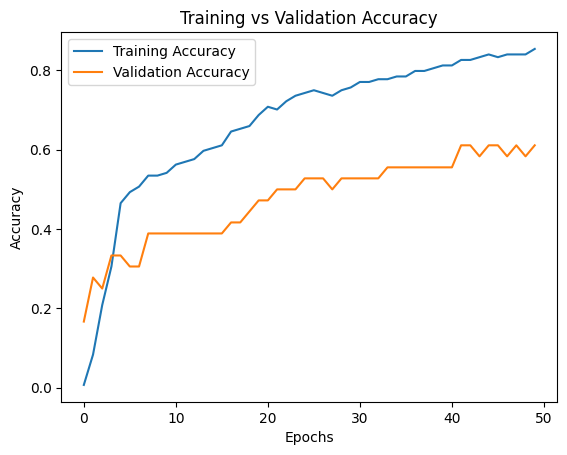

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

In [17]:
# 12. TEST CASES (NEW STUDENTS)
# ---------------------------------
print("\n=== TEST CASES ===")


test_students = np.array([

    [1, 21, 3.5, 0, 1, 0, 1, 1, 1], # Student 1
    [0, 20, 3.2, 1, 55, 1, 1, 1, 1], # Student 2
    [1, 55, 3.8, 1, 1, 1, 1, 1, 1]  # Student 3
])


actual_feature_names = data.drop(columns=['Student ID', 'Name', 'Future Career']).columns.tolist()


test_students_df = pd.DataFrame(test_students, columns=actual_feature_names)

# Scale input
test_students_scaled = scaler.transform(test_students_df)

# Predict
predictions = model.predict(test_students_scaled)
predicted_classes = np.argmax(predictions, axis=1)

# Convert to career names
predicted_careers = le.inverse_transform(predicted_classes)

# Output results
for i, career in enumerate(predicted_careers):
    print(f"Student {i+1} Recommended Career: {career}")


=== TEST CASES ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Student 1 Recommended Career: Cloud Solutions Architect
Student 2 Recommended Career: Web Developer
Student 3 Recommended Career: Cloud Solutions Architect


In [18]:
print("\n=== MODEL EVALUATION ===")

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))



=== MODEL EVALUATION ===
Accuracy: 0.6111111111111112

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           3       0.83      1.00      0.91         5
           5       0.33      1.00      0.50         1
           7       1.00      1.00      1.00         1
           8       0.50      1.00      0.67         2
          11       0.00      0.00      0.00         1
          13       0.00      0.00      0.00         1
          14       1.00      1.00      1.00         1
          16       0.33      1.00      0.50         1
          17       0.00      0.00      0.00         1
          18       0.67      1.00      0.80         2
          19       0.00      0.00      0.00         1
          20       1.00      0.50      0.67         2
          22       1.00      0.30      0.46        10
          24       0.00      0.00      0.00         0
  